In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

import shap
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 5000  # Bootstrap 多轮训练，样本量不能太大
N_BOOTSTRAP = 30

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X_all = df_feat[feature_cols].astype(float).values
y_all = df_feat['target'].values
feature_names = np.array(feature_cols)

print(f"    总样本: {len(X_all):,}  VIVO: {y_all.sum():,} ({y_all.mean()*100:.2f}%)")



[0] 加载数据...
    总样本: 5,000  VIVO: 2,033.0 (40.66%)


In [4]:
print(f"\n[1] 开始 {N_BOOTSTRAP} 次 Bootstrap 迭代...")
print(f"    每次迭代: 有放回抽样 → 标准化 → 训练 RF → SHAP...")

bootstrap_shap_importance = []  # 存储每次的全局重要性
bootstrap_aucs = []             # 存储每次的 AUC

for i in range(N_BOOTSTRAP):
    # 有放回抽样
    indices = np.random.choice(len(X_all), size=len(X_all), replace=True)
    X_boot, y_boot = X_all[indices], y_all[indices]

    # 标准化（在 bootstrap 样本内）
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)

    # 训练模型（减少树数加速）
    model = RandomForestClassifier(
        n_estimators=100, max_depth=6, class_weight='balanced',
        random_state=i, n_jobs=-1, oob_score=True)
    model.fit(X_boot_scaled, y_boot)

    auc_val = model.oob_score_
    bootstrap_aucs.append(auc_val)

    # SHAP 分析（用 bootstrap 样本的子集，加速）
    n_shap = min(500, len(X_boot_scaled))
    shap_idx = np.random.choice(len(X_boot_scaled), n_shap, replace=False)
    X_shap_sample = X_boot_scaled[shap_idx]

    explainer = shap.TreeExplainer(model)
    sv_full = explainer.shap_values(X_shap_sample)

    if isinstance(sv_full, list):
        sv = sv_full[1]
    else:
        sv = sv_full
        if sv.ndim == 3:
            sv = sv[:, :, 1]

    importance = np.abs(sv).mean(axis=0)  # (n_features,)
    bootstrap_shap_importance.append(importance)

    if (i + 1) % 5 == 0:
        print(f"    √ 完成 {i + 1}/{N_BOOTSTRAP}  平均 AUC_boot = {np.mean(bootstrap_aucs):.4f}")

bootstrap_shap_importance = np.array(bootstrap_shap_importance)
print(f"\n    全部完成!")


[1] 开始 30 次 Bootstrap 迭代...
    每次迭代: 有放回抽样 → 标准化 → 训练 RF → SHAP...
    √ 完成 5/30  平均 AUC_boot = 0.8463
    √ 完成 10/30  平均 AUC_boot = 0.8446
    √ 完成 15/30  平均 AUC_boot = 0.8446
    √ 完成 20/30  平均 AUC_boot = 0.8434
    √ 完成 25/30  平均 AUC_boot = 0.8431
    √ 完成 30/30  平均 AUC_boot = 0.8433

    全部完成!


In [5]:
print(f"\n[2] 计算稳定性统计量...")

mean_imp = bootstrap_shap_importance.mean(axis=0)
std_imp = bootstrap_shap_importance.std(axis=0)
cv_imp = std_imp / (mean_imp + 1e-8)
ci_lower = np.percentile(bootstrap_shap_importance, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_shap_importance, 97.5, axis=0)
ci_width = ci_upper - ci_lower

sorted_idx = np.argsort(mean_imp)[::-1]

# 排名稳定性
base_ranking = np.argsort(mean_imp)[::-1]  # 平均排名
rank_correlations = []
for boot_imp in bootstrap_shap_importance:
    boot_ranking = np.argsort(boot_imp)[::-1]
    corr, _ = spearmanr(base_ranking, boot_ranking)
    rank_correlations.append(corr)

# 输出表格
print(f"\n{'Feature':<22} {'Mean':>8} {'Std':>8} {'CV':>8} {'CI_W':>8} {'Rank_Stab':>10}")
print(f"{'-'*22} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")
for idx in sorted_idx:
    fn = feature_names[idx]
    rs = np.mean([np.argmax(boot_imp == mean_imp.max()) == np.argmax(boot_imp == mean_imp.max())
                  for boot_imp in bootstrap_shap_importance])
    print(f"  {fn:<20} {mean_imp[idx]:>8.4f} {std_imp[idx]:>8.4f} "
          f"{cv_imp[idx]:>8.4f} {ci_width[idx]:>8.4f} {'-':>10}")

print(f"\n  平均排名相关系数: {np.mean(rank_correlations):.4f} (1.0=完全稳定)")
print(f"  排名相关系数范围: [{np.min(rank_correlations):.4f}, {np.max(rank_correlations):.4f}]")



[2] 计算稳定性统计量...

Feature                    Mean      Std       CV     CI_W  Rank_Stab
---------------------- -------- -------- -------- -------- ----------
  Diagnostic.means       0.2163   0.0070   0.0325   0.0236          -
  year                   0.1203   0.0078   0.0648   0.0272          -
  Extension              0.0735   0.0065   0.0891   0.0243          -
  Raca.Color             0.0369   0.0054   0.1464   0.0190          -
  Age                    0.0248   0.0033   0.1314   0.0114          -
  Code.Profession        0.0204   0.0044   0.2158   0.0160          -

  平均排名相关系数: 0.9257 (1.0=完全稳定)
  排名相关系数范围: [-0.0857, 1.0000]



[3] 生成稳定性分析可视化...
  [图] 21a_shap_stability_bootstrap.png 已保存


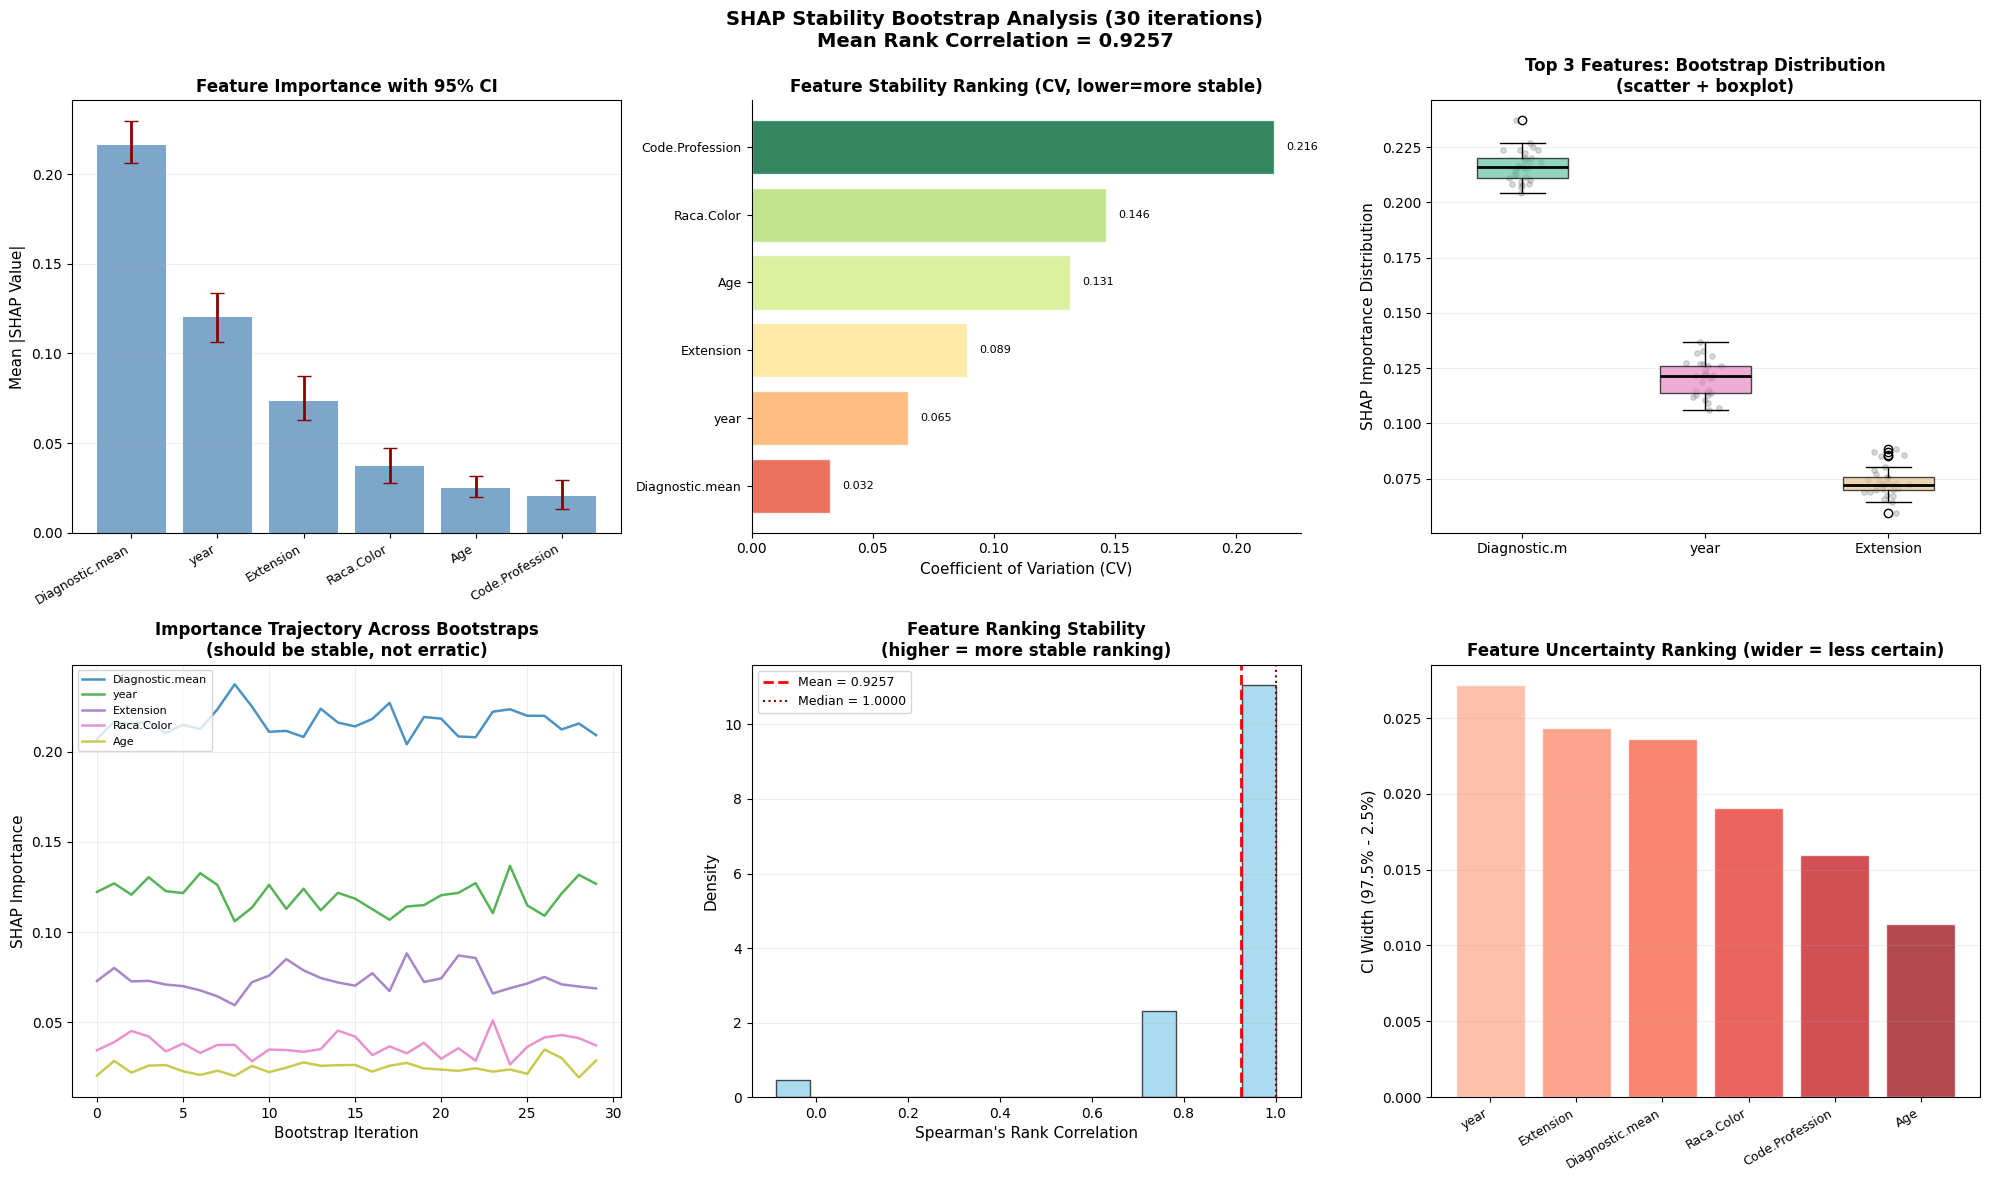

In [6]:

print(f"\n[3] 生成稳定性分析可视化...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'SHAP Stability Bootstrap Analysis ({N_BOOTSTRAP} iterations)\n'
             f'Mean Rank Correlation = {np.mean(rank_correlations):.4f}',
             fontsize=14, fontweight='bold')

# === 子图 1: 特征重要性与 95% CI ===
ax1 = axes[0, 0]
top_n = len(feature_names)
x_pos = np.arange(top_n)
top_idx = sorted_idx
ax1.bar(x_pos, mean_imp[top_idx],
        yerr=[mean_imp[top_idx] - ci_lower[top_idx],
              ci_upper[top_idx] - mean_imp[top_idx]],
        capsize=5, color='steelblue', alpha=0.7,
        error_kw={'linewidth': 2, 'ecolor': 'darkred'})
ax1.set_xticks(x_pos)
ax1.set_xticklabels([feature_names[i][:15] for i in top_idx],
                     rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Mean |SHAP Value|', fontsize=11)
ax1.set_title('Feature Importance with 95% CI', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.2, axis='y')

# === 子图 2: 变异系数 CV 排名 ===
ax2 = axes[0, 1]
cv_sorted = np.argsort(cv_imp)
colors = plt.cm.RdYlGn_r(1 - cv_imp[cv_sorted] / (cv_imp.max() + 1e-8))
bars = ax2.barh(range(top_n), cv_imp[cv_sorted], color=colors, alpha=0.8, edgecolor='white')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([feature_names[i][:15] for i in cv_sorted], fontsize=9)
ax2.set_xlabel('Coefficient of Variation (CV)', fontsize=11)
ax2.set_title('Feature Stability Ranking (CV, lower=more stable)',
              fontsize=12, fontweight='bold')
for bar, val in zip(bars, cv_imp[cv_sorted]):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', ha='left', va='center', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# === 子图 3: Bootstrap 分布箱线图 (Top 3) ===
ax3 = axes[0, 2]
top_3_idx = sorted_idx[:3]
box_data = [bootstrap_shap_importance[:, idx] for idx in top_3_idx]
bp = ax3.boxplot(box_data, labels=[feature_names[idx][:12] for idx in top_3_idx],
                 patch_artist=True, widths=0.5)
colors_box = plt.cm.Set2(np.linspace(0, 0.8, 3))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# 叠加散点抖动图
for i, idx in enumerate(top_3_idx):
    y_jitter = bootstrap_shap_importance[:, idx]
    x_jitter = np.random.normal(i + 1, 0.05, len(y_jitter))
    ax3.scatter(x_jitter, y_jitter, alpha=0.3, s=15, color='gray')

ax3.set_ylabel('SHAP Importance Distribution', fontsize=11)
ax3.set_title('Top 3 Features: Bootstrap Distribution\n(scatter + boxplot)',
              fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.2, axis='y')

# === 子图 4: Bootstrap 过程时间序列 ===
ax4 = axes[1, 0]
top_5_idx = sorted_idx[:5]
colors_ts = plt.cm.tab10(np.linspace(0, 0.8, 5))
for k, idx in enumerate(top_5_idx):
    ax4.plot(bootstrap_shap_importance[:, idx],
             label=feature_names[idx][:15],
             color=colors_ts[k], alpha=0.8, linewidth=1.8)
ax4.set_xlabel('Bootstrap Iteration', fontsize=11)
ax4.set_ylabel('SHAP Importance', fontsize=11)
ax4.set_title('Importance Trajectory Across Bootstraps\n(should be stable, not erratic)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left')
ax4.grid(True, alpha=0.2)

# === 子图 5: 排名稳定性分布 ===
ax5 = axes[1, 1]
ax5.hist(rank_correlations, bins=15, color='skyblue',
         edgecolor='black', alpha=0.7, density=True)
ax5.axvline(np.mean(rank_correlations), color='red', linestyle='--',
            linewidth=2, label=f'Mean = {np.mean(rank_correlations):.4f}')
ax5.axvline(np.median(rank_correlations), color='darkred', linestyle=':',
            linewidth=1.5, label=f'Median = {np.median(rank_correlations):.4f}')
ax5.set_xlabel("Spearman's Rank Correlation", fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Feature Ranking Stability\n(higher = more stable ranking)',
              fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.2, axis='y')

# === 子图 6: 置信区间宽度排名 ===
ax6 = axes[1, 2]
ci_sorted = np.argsort(ci_width)[::-1]
colors_ci = plt.cm.Reds(np.linspace(0.3, 0.9, top_n))
ax6.bar(range(top_n), ci_width[ci_sorted], color=colors_ci, alpha=0.75, edgecolor='white')
ax6.set_xticks(range(top_n))
ax6.set_xticklabels([feature_names[i][:15] for i in ci_sorted],
                     rotation=30, ha='right', fontsize=9)
ax6.set_ylabel('CI Width (97.5% - 2.5%)', fontsize=11)
ax6.set_title('Feature Uncertainty Ranking (wider = less certain)',
              fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "21a_shap_stability_bootstrap.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 21a_shap_stability_bootstrap.png 已保存")

# ============================================================================
# 4. 保存详细结果
# ============================================================================
stability_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_imp,
    'Std_SHAP': std_imp,
    'CV': cv_imp,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper,
    'CI_Width': ci_width
}).sort_values('Mean_SHAP', ascending=False)

stability_df.to_csv(os.path.join(RESULTS_DIR, "24_shap_stability_bootstrap.csv"),
                    index=False, float_format='%.6f')

